<a href="https://colab.research.google.com/github/SpartanMaster-117/Gundam/blob/Alexander/HW5_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## HW5 Classification and performance evaluation - part II

In this homework, we will practice building classification models using logistic regression and decision trees, and evaluate their performance.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import linear_model
from sklearn import metrics
from sklearn import preprocessing as prep

### Load and insepect data  

The data we used is california housing price data set from sklearn. This dataset is somewhat similar to the Boston housing price dataset, with fewer columns / features but more rows. For classification task, the price is converted to two categories: high or low, using an arbitary threshold.

In [ ]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing() # housing is a dictionary
print (housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
data = pd.DataFrame(housing['data'], columns = housing['feature_names']) # pandas dataframe
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


Text(0, 0.5, 'Count')

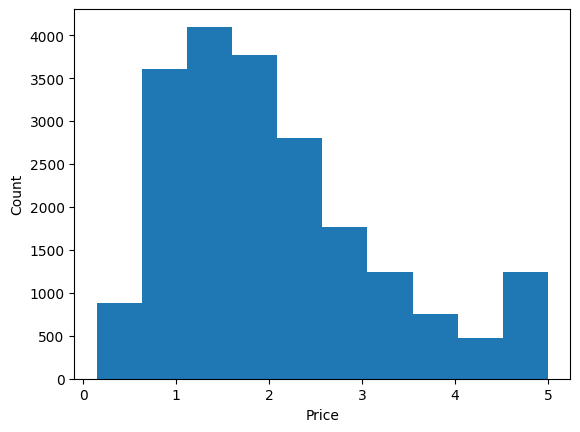

In [ ]:
price = housing['target'] # price is a 1D numpy array
plt.hist(price)
plt.xlabel('Price')
plt.ylabel('Count')

### Define X and y for classification tasks

In [ ]:
from sklearn import model_selection as ms
X = prep.StandardScaler().fit_transform(data) # X is z-score normalized data

y = (price > 2.5).astype(int) # y value will be 1 if price is higher than a threshold = 2.5 (class-1:high-price), and 0 otherwise (class-0:low-price)


# the following code splits the rows of X randomly into X_train and X_test, and
# the corresponding y into y_train and y_test
# 70% of the data goes into training, and 30% to testing

X_train, X_test, y_train, y_test = ms.train_test_split(X, y, test_size=0.3, random_state=1)

[len(y_train), len(y_test)] # show the number of instances in training and testing

[14448, 6192]

In [ ]:
pd.DataFrame(X).describe()

,0,1,2,3,4,5,6,7
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,6.609700e-17,5.508083e-18,6.609700e-17,-1.060306e-16,-1.101617e-17,3.442552e-18,-1.079584e-15,-8.526513e-15
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-1.774299e+00,-2.196180e+00,-1.852319e+00,-1.610768e+00,-1.256123e+00,-2.290000e-01,-1.447568e+00,-2.385992e+00
25%,-6.881186e-01,-8.453931e-01,-3.994496e-01,-1.911716e-01,-5.638089e-01,-6.171062e-02,-7.967887e-01,-1.113209e+00
50%,-1.767951e-01,2.864572e-02,-8.078489e-02,-1.010650e-01,-2.291318e-01,-2.431585e-02,-6.422871e-01,5.389137e-01
75%,4.593063e-01,6.643103e-01,2.519615e-01,6.015869e-03,2.644949e-01,2.037453e-02,9.729566e-01,7.784964e-01
max,5.858286e+00,1.856182e+00,5.516324e+01,6.957171e+01,3.025033e+01,1.194191e+02,2.958068e+00,2.625280e+00


## Task 1. Classification and performance evaluation with logistic regression

### Task 1.1 (8 points) Model training
Provide your code below to train a logistic regression model using X_train and y_train, and show the cofficients of the logistic regression as a horizontal bar chart (barh). Label the plot with feature names.

In [ ]:
print()

### Task 1.2 (2 points) Model interpretation

Question - based on the plot above, which feature has the most positive contribution towards price and which feature the most negative?

Your answer:

### Task 1.3	(5 pts) Performance on training data
Use the model learned to predict labels for the *training data* and output the following: confusion matrix, accuracy, precision, recall, F-1 score and kappa. (These functions are available in sklearn.metrics.)

### Task 1.4 (5 points) Performance on testing data
Use the model learned to predict labels for the *testing data* and output the following: confusion matrix, accuracy, precision, recall, F-1 score and kappa. (These functions are available in sklearn.metrics if you don’t want to define your own.)

### Task 1.5.	(5 pts) 10-fold cross validation
Perform a 10-fold stratified cross-validation and  output the same metrics as required in 1.2: confusion matrix, accuracy, precision, recall, F-1 score and kappa. (Use sklearn.model_selection.cross_val_predict.)

### Task 1.6	(5 pts) ROC curve and AUC score

Using logistic regression model, perform a 10-fold cross-validation on the entire X and y to get the predicted probabilities with sklearn.model_selection.cross_val_predict, method = 'predict_proba'. Use the returned probability values to plot the ROC curve, and compute the AUC score. Show the AUC score in the bottom-right corner of the ROC plot.

## Task 2. Classification and performance evaluation using decision trees

### Task 2.1 (8 points) Decision tree training
Train a decision tree classifier using X_train and y_train, with parameter max_depth set to 2. Show a figure of the decision tree using sklearn.tree.plot_tree.


### Task 2.2 (2 points) Model intepretation
For an instance with x[0] = -1 and x[5] = 2, which leaf node (1 - 4, left to right) will be used to classify the instance and what is the predicted label  (class-0:low-price or class-1:high-price)?

Your answer here:

### Task 2.3 (5 points) Performance on training data

Use the decision tree trained above to predict labels for the training data and output the following: confusion matrix, accuracy, precision, recall, F-1 score and kappa.

### Task 2.4 (5 points) Performance on testing data

Use the decision tree model trained above to predict labels for the *testing data* and output the following: confusion matrix, accuracy, precision, recall, F-1 score and kappa.

### Task 2.5 (8 points). Expriment to study overfitting

Now construct a series of decision trees (using a for loop) with max_depth set to 1, 2, 3, ..., 25. Use each decision tree to predict labels for the training data and test data, and record the corresponding f1-scores. Make a line graph between the max_depth (x-axis) and F-1 scores (y-axis). Label your figures, and use legend to show which line is for training data and which line is for testing data.

### Task 2.6 (2 points) Question
Based on the figure above, at approximately what max-depth value did the algorithm start over-fitting the data and why?

Your answer here:

## Task 3: (Bonus 10 points) Ensemble classifier

Train a Random Forest Classifier using X_train and y_train, use it to make predictions on X_test and print out the the Precision, Recall, and F-1 score. Repeat for Gradient Boosting Classifier. Use n_estimator = 100.
(For your satisfaction: compare their F-1 score with Logistic Regression and Decision Tree classifiers.)